# 📗 딥러닝 기초 종합 과제

## 손글씨 숫자 분류 모델의 학습·비교·저장·추론 흐름 완성하기

여러분은 손글씨 숫자 판독 기능을 점검하는 AI 개발팀의 구성원입니다. 이번 과제에서는
정확도 하나만 확인하지 않고 `데이터 → 모델 → 학습·검증 → 비교 → 저장·복원 → 추론`의
전체 흐름을 완성합니다.

> ✅ **4점은 필수 역량을 모두 달성한 상 수준**입니다. 5점은 4점 기준을 먼저 충족한 뒤
> 해당 문제의 선택 심화를 구현·검증·해석한 +α입니다.

### 🧭 진행 순서

1. 문제 1~4의 필수 TODO를 순서대로 완성합니다.
2. 각 코드 셀 아래 자동 검증이 `PASS`인지 확인합니다.
3. 실제 출력과 그래프를 근거로 설명 답안을 작성합니다.
4. 시간이 남으면 원하는 5점 도전을 수행합니다.
5. 마지막 셀에서 필수 B1~B4가 모두 `PASS`인지 확인합니다.

절대 accuracy는 채점하지 않습니다. 올바른 split, 학습·검증 흐름, 공정 비교,
checkpoint 복원과 출력 기반 해석을 평가합니다.


## 0. 🛠️ 환경과 공통 설정

이 과제는 외부 이미지 파일을 내려받지 않는 `load_digits`를 사용합니다. 무료 Colab에서
GPU가 배정되지 않아도 전체 흐름을 실행할 수 있습니다.

### 먼저 확인할 것

- 실행 장치가 CPU인지 GPU인지
- Python·PyTorch·scikit-learn 버전
- seed·batch size·learning rate·최대 epoch·Early Stopping 설정
- 데이터의 원본 shape와 class 수

> 🔒 문제 1~3에서는 test index만 예약합니다. test `Dataset`과 `DataLoader`는 모델과
> checkpoint가 모두 확정된 문제 4의 마지막 단계에서만 만듭니다.


In [1]:
import copy
import hashlib
import importlib.util
import inspect
import json
import os
import platform
import random
import subprocess
import sys
from pathlib import Path

# Colab 기본 runtime에 없는 package만 설치합니다.
required_modules = {
    "torch": "torch",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
}
missing_packages = [
    package
    for module, package in required_modules.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages and os.environ.get("DL_ASSIGNMENT_SKIP_INSTALL") != "1":
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import torch
import torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import (
    DataLoader,
    RandomSampler,
    SequentialSampler,
    TensorDataset,
)

SEED = 42
BATCH_SIZE = 64
LEARNING_RATE = 0.005
EPOCHS = 30  # 최대 epoch
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 0.002
NUM_CLASSES = 10
DROPOUT_RATE = 0.2

TODO_IDS = [
    "TODO-B1-SPLIT-1", "TODO-B1-SPLIT-2", "TODO-B1-LOADER-1",
    "TODO-B1-LOADER-2", "TODO-B1-NCHW", "TODO-B1-DEVICE-1",
    "TODO-B1-DEVICE-2", "TODO-B1-CONTRACT", "TODO-B1-CHALLENGE",
    "TODO-B2-MLP", "TODO-B2-CNN", "TODO-B2-SHAPE-1",
    "TODO-B2-SHAPE-2", "TODO-B2-SHAPE-3", "TODO-B2-PARAMS",
    "TODO-B2-LOSS", "TODO-B2-OPT-MLP", "TODO-B2-OPT-CNN",
    "TODO-B2-MODE", "TODO-B2-CHALLENGE",
    "TODO-B3-TRAIN-1", "TODO-B3-TRAIN-2", "TODO-B3-TRAIN-3",
    "TODO-B3-TRAIN-4", "TODO-B3-TRAIN-5", "TODO-B3-TRAIN-6",
    "TODO-B3-TRAIN-7", "TODO-B3-TRAIN-8",
    "TODO-B3-VALID-1", "TODO-B3-VALID-2",
    "TODO-B3-VALID-3", "TODO-B3-VALID-4", "TODO-B3-CURVE",
    "TODO-B3-CHALLENGE",
    "TODO-B4-BEST", "TODO-B4-CHECKPOINT", "TODO-B4-LAST-CHECKPOINT", "TODO-B4-SAVE",
    "TODO-B4-LOAD-MODEL", "TODO-B4-LOAD-LAST-MODEL", "TODO-B4-LOAD-OPT", "TODO-B4-START",
    "TODO-B4-RESUME", "TODO-B4-INFERENCE", "TODO-B4-CHALLENGE",
]

def set_all_seeds(seed=SEED):
    # Python·NumPy·PyTorch의 난수 시작점을 고정합니다.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # cuDNN을 사용하는 경우에도 가능한 범위에서 결정적 경로를 선택합니다.
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_all_seeds()
# 작은 CPU 과제에서는 thread 수를 줄이면 실행 편차와 overhead가 작아집니다.
torch.set_num_threads(1)

DEVICE = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)

def TODO(message):
    raise NotImplementedError(f"TODO를 완성하세요: {message}")

ENVIRONMENT = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "sklearn": sklearn.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(DEVICE) if DEVICE.type == "cuda" else None,
    "seed": SEED,
    "max_epochs": EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
}
print(json.dumps(ENVIRONMENT, ensure_ascii=False, indent=2))


{
  "python": "3.14.4",
  "torch": "2.13.0+cu130",
  "sklearn": "1.9.0",
  "numpy": "2.5.2",
  "matplotlib": "3.11.1",
  "device": "cuda:0",
  "gpu": "NVIDIA GeForce RTX 5060 Laptop GPU",
  "seed": 42,
  "max_epochs": 30,
  "early_stopping_patience": 3,
  "early_stopping_min_delta": 0.002
}


In [2]:
# load_digits는 package에 포함된 toy dataset이므로 데이터 파일 다운로드가 없습니다.
digits = load_digits()
source_images = digits.images.astype(np.float32) # type: ignore
source_labels = digits.target.astype(np.int64) # type: ignore

# 원래 0~16 범위의 픽셀을 0~1로 정규화하고 grayscale channel을 추가합니다.
images_all = torch.from_numpy(source_images).unsqueeze(1) / 16.0
labels_all = torch.from_numpy(source_labels)
all_indices = np.arange(len(source_labels), dtype=np.int64)

source_fingerprint = hashlib.sha256(
    source_images.tobytes() + source_labels.tobytes()
).hexdigest()

assert images_all.shape == (1797, 1, 8, 8)
assert images_all.dtype == torch.float32
assert labels_all.shape == (1797,)
assert labels_all.dtype == torch.int64
print(
    {
        "samples": len(labels_all),
        "image_shape": tuple(images_all.shape[1:]),
        "classes": sorted(labels_all.unique().tolist()),
        "normalized_pixel_min": float(images_all.min()),
        "normalized_pixel_max": float(images_all.max()),
        "source_fingerprint": source_fingerprint,
    }
)


{'samples': 1797, 'image_shape': (1, 8, 8), 'classes': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'normalized_pixel_min': 0.0, 'normalized_pixel_max': 1.0, 'source_fingerprint': 'faf2d98f61250c1cdc0b114323133d3c58da04f5c5d28bb78e4bde3c936a75b1'}


# 1. 🧱 데이터 분할·DataLoader·배치 입구 검사

## 문제 배경

모델에 들어가는 배치의 shape나 dtype이 잘못되면 학습이 시작되지 않거나 잘못된 계산이
진행될 수 있습니다. 이번 문제에서는 데이터를 누수 없이 나누고, 첫 배치가 모델이 기대하는
규칙을 지키는지 확인합니다.

## 이 문제에서 배우는 것

- **stratified split:** 숫자 0~9의 비율을 가능한 한 유지하며 데이터 나누기
- **NCHW:** 이미지 Tensor의 표준 순서 `[배치, 채널, 높이, 너비]`
- **device:** 모델과 Tensor가 계산되는 CPU 또는 GPU
- **batch contract:** 모델에 들어가기 전 배치가 지켜야 할 입구 규칙

## 수행 순서

1. seed 42로 70/15/15 train·validation·test index를 만듭니다.
2. train은 shuffle, validation은 고정 순서로 DataLoader를 만듭니다.
3. 일부러 NHWC가 된 batch를 NCHW로 되돌리고 값 보존을 검사합니다.
4. image·label을 모델과 같은 device로 이동합니다.
5. shape·dtype·finite·label 범위·device를 모두 검사합니다.

## 제출 결과물

- split 크기·class 분포·교집합 0 확인
- sampler 종류와 첫 batch 정보
- NHWC → NCHW 수정 전후 shape
- 배치 입구 검사 결과와 `문제 1 필수 자동 검증: PASS`

## ⚠️ 자주 발생하는 실수

- validation이나 test까지 shuffle해야 성능이 좋아진다고 오해하기
- NHWC를 NCHW로 바꾸는 `permute()` 순서를 반대로 작성하기
- image만 device로 옮기고 label은 CPU에 남겨두기
- 다중 분류 label을 `float32`로 바꾸기

## 🚀 5점 도전 미리보기

첫 오류에서 멈추지 않고 여러 오류를 한 번에 모아 보여 주는 검사기를 만듭니다.


In [3]:
# 첫 split에서 70% train과 30% remainder를 만듭니다.
train_indices, remainder_indices = train_test_split(
    all_indices,
    test_size=0.3,
    stratify=source_labels
)

# remainder를 같은 크기의 validation/test로 나눠 전체 70/15/15를 만듭니다.
valid_indices, final_test_indices = train_test_split(
    remainder_indices,
    test_size=0.5,
    stratify=source_labels[remainder_indices]
)

# 세 split의 교집합이 없고 모든 sample을 정확히 한 번 포함하는지 검사합니다.
train_index_set = set(map(int, train_indices))
valid_index_set = set(map(int, valid_indices))
test_index_set = set(map(int, final_test_indices))
assert train_index_set.isdisjoint(valid_index_set)
assert train_index_set.isdisjoint(test_index_set)
assert valid_index_set.isdisjoint(test_index_set)
assert len(train_index_set | valid_index_set | test_index_set) == len(all_indices)
assert (len(train_indices), len(valid_indices), len(final_test_indices)) == (1257, 270, 270)

# 각 split에 0~9 class가 모두 존재하는지도 확인합니다.
assert set(source_labels[train_indices]) == set(range(NUM_CLASSES))
assert set(source_labels[valid_indices]) == set(range(NUM_CLASSES))
assert set(source_labels[final_test_indices]) == set(range(NUM_CLASSES))

split_fingerprint = hashlib.sha256(
    np.concatenate(
        [
            np.sort(train_indices),
            np.array([-1], dtype=np.int64),
            np.sort(valid_indices),
            np.array([-2], dtype=np.int64),
            np.sort(final_test_indices),
        ]
    ).astype(np.int64).tobytes()
).hexdigest()

# 문제 1~3에서는 train/validation Dataset만 생성합니다.
train_dataset = TensorDataset(
    images_all[train_indices], labels_all[train_indices]
)
valid_dataset = TensorDataset(
    images_all[valid_indices], labels_all[valid_indices]
)

# 모델별로 같은 shuffle 순서를 재생성할 수 있는 factory입니다.
def make_train_loader(seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=generator,
    )

# 문제 1 검사용 train/validation loader를 만듭니다.
train_loader = make_train_loader()
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

assert isinstance(train_loader.sampler, RandomSampler)
assert isinstance(valid_loader.sampler, SequentialSampler)
assert train_loader.batch_size == valid_loader.batch_size == BATCH_SIZE
assert train_loader.dataset is train_dataset
assert valid_loader.dataset is valid_dataset
assert len(train_loader.dataset) == len(train_indices) # type: ignore
assert len(valid_loader.dataset) == len(valid_indices) # type: ignore

batch_images, batch_labels = next(iter(train_loader))
# 일부 이미지 도구의 NHWC 오류를 의도적으로 재현합니다.
batch_nhwc = batch_images.permute(0, 2, 3, 1).contiguous()

def restore_nchw(batch):
    # TODO-B1-NCHW: 입력으로 받은 NHWC만 사용해 NCHW를 복원합니다.

    return batch.permute(0, 3, 1, 2)

restored_nchw = restore_nchw(batch_nhwc)
# 함수가 받은 NHWC와 복원한 NCHW의 왕복 값 보존을 비교합니다.
torch.testing.assert_close(
    restored_nchw.permute(0, 2, 3, 1), batch_nhwc
)

# 작은 Conv2d의 parameter device를 batch 이동 기준으로 사용합니다.
device_probe = nn.Conv2d(1, 4, kernel_size=3, padding=1).to(DEVICE)
expected_device = next(device_probe.parameters()).device
images_device = restored_nchw.to(expected_device)
labels_device = batch_labels.to(expected_device)

# device 이동 전후 값이 그대로인지도 검사합니다.
torch.testing.assert_close(images_device.cpu(), restored_nchw)
torch.testing.assert_close(labels_device.cpu(), batch_labels)

def assert_batch_contract(images, labels, device):
    # TODO-B1-CONTRACT: 아래 모든 계약을 fail-fast 방식으로 검사합니다.
    assert len(images) > 0
    assert labels.shape == (len(images),)
    assert images.device == device
    assert labels.device == device
    assert images.shape[1:] == (1, 8, 8)
    assert images.dtype == torch.float32
    assert labels.dtype == torch.long
    assert torch.isfinite(images).all()
    assert ((labels >= 0) & (labels < NUM_CLASSES)).all()

    return {
        "batch": len(images),
        "image_shape": tuple(images.shape),
        "image_dtype": str(images.dtype),
        "label_dtype": str(labels.dtype),
        "label_min": int(labels.min().item()),
        "label_max": int(labels.max().item()),
        "device": str(device),
    }

batch_contract_report = assert_batch_contract(
    images_device, labels_device, expected_device
)
probe_logits = device_probe(images_device)
assert probe_logits.shape == (len(images_device), 4, 8, 8)
assert torch.isfinite(probe_logits).all()

SPLIT_SUMMARY = {
    "train": len(train_indices),
    "validation": len(valid_indices),
    "test_reserved": len(final_test_indices),
    "split_fingerprint": split_fingerprint,
}
PROBLEM_1_EVIDENCE = {
    "class_distribution": {
        "train": np.bincount(
            source_labels[train_indices], minlength=NUM_CLASSES
        ).tolist(),
        "validation": np.bincount(
            source_labels[valid_indices], minlength=NUM_CLASSES
        ).tolist(),
        "test_reserved": np.bincount(
            source_labels[final_test_indices], minlength=NUM_CLASSES
        ).tolist(),
    },
    "samplers": {
        "train": type(train_loader.sampler).__name__,
        "validation": type(valid_loader.sampler).__name__,
    },
    "shape_conversion": {
        "nhwc_before": list(batch_nhwc.shape),
        "nchw_after": list(restored_nchw.shape),
        "roundtrip_values_preserved": True,
    },
}
CORE_B1_PASS = True
print("문제 1 필수 자동 검증: PASS")
print(json.dumps(SPLIT_SUMMARY, ensure_ascii=False, indent=2))
print(json.dumps(PROBLEM_1_EVIDENCE, ensure_ascii=False, indent=2))
print(batch_contract_report)


문제 1 필수 자동 검증: PASS
{
  "train": 1257,
  "validation": 270,
  "test_reserved": 270,
  "split_fingerprint": "4b5fcd0e3da756908d27ebe892f5d427952399e444de527a2dd5f8262599d44a"
}
{
  "class_distribution": {
    "train": [
      124,
      127,
      124,
      128,
      127,
      127,
      127,
      125,
      122,
      126
    ],
    "validation": [
      27,
      28,
      26,
      28,
      27,
      27,
      27,
      27,
      26,
      27
    ],
    "test_reserved": [
      27,
      27,
      27,
      27,
      27,
      28,
      27,
      27,
      26,
      27
    ]
  },
  "samplers": {
    "train": "RandomSampler",
    "validation": "SequentialSampler"
  },
  "shape_conversion": {
    "nhwc_before": [
      64,
      8,
      8,
      1
    ],
    "nchw_after": [
      64,
      1,
      8,
      8
    ],
    "roundtrip_values_preserved": true
  }
}
{'batch': 64, 'image_shape': (64, 1, 8, 8), 'image_dtype': 'torch.float32', 'label_dtype': 'torch.int64', 'label_min': 0,

### ✍️ 문제 1 필수 결과 해석 - 직접 작성

실제 출력값을 인용하여 아래 세 질문에 답하세요.

1. stratified 70/15/15 split과 train-only shuffle이 필요한 이유를 2문장으로 설명하세요.
2. NHWC를 NCHW로 되돌리고, image·label·model을 같은 device에 둬야 하는 이유를 2문장으로 설명하세요.
3. 실제 `batch_contract_report`의 image shape·dtype·label 범위·device를 기록하세요.

> **답안 작성 공간**  
> 1. 
>   - 0~9 숫자 비율을 가능한 한 유지하면서 데이터를 나누기 위해서.
>   - 학습 단계에서 shuffle을 하지 않으면 매번 같은 순서 및 배치 조합으로 학습하기에 영향을 줄이기 위해 섞는다. validation은 가중치를 업데이트 하지 않고 동일한 환경에서 평가하므로, 고정 순서로 평가하기 위해 shuffle을 하지 않는다.
> 2.
>   - Conv2d는 NCHW로 받아야 하므로
>   - device가 다르면 연산이 불가능 하므로  
> 3.
>   - image shape: (64, 1, 8, 8)
>   - dtype: torch.float32
>   - label범위: 0 ~ 9
>   - device: cuda


In [4]:
# 과제가 쉬웠다면 도전해보세요! - 5점 도전 B1
CHALLENGE_B1_DONE = True
CHALLENGE_B1_PASS = False

def collect_batch_contract_errors(images, labels, device):
    if not CHALLENGE_B1_DONE:
        return []

    errors = []

    if labels.shape != (images.shape[0],):
        errors.append("label_shape")

    if images.ndim != 4 or images.shape[1:] != (1, 8, 8):
        errors.append("image_shape")

    if images.dtype != torch.float32:
        errors.append("image_dtype")

    if labels.dtype != torch.long:
        errors.append("label_dtype")

    if not ((labels >= 0) & (labels < NUM_CLASSES)).all():
        errors.append("label_range")



    # shape/dtype/finite/label/device의 모든 오류명을 list로 모으세요.
    return errors

if CHALLENGE_B1_DONE:
    broken_images = batch_nhwc.to(expected_device, dtype=torch.float64)
    broken_labels = labels_device.clone()
    broken_labels[0] = NUM_CLASSES
    broken_labels[1] = -1
    detected_errors = collect_batch_contract_errors(
        broken_images, broken_labels, expected_device
    )
    expected_errors = {"image_shape", "image_dtype", "label_range"}
    assert expected_errors <= set(detected_errors)
    CHALLENGE_B1_PASS = True
    print("5점 도전 B1 자동 검증: PASS", detected_errors)
else:
    print("5점 도전 B1: SKIPPED - 필수 점수 감점 없음")


5점 도전 B1 자동 검증: PASS ['image_shape', 'image_dtype', 'label_range']


### 🚀 5점 도전 B1 결과 해석 - 수행한 경우 작성

이번 도전의 `fail-fast`는 “첫 오류에서 즉시 중단하는 방식”을 뜻합니다.

1. 실제 `detected_errors` 목록을 기록하세요.
2. 여러 오류를 한 번에 모으는 방식이 첫 오류에서 멈추는 방식보다 디버깅에 유리한 점을
   2문장으로 설명하세요.

> **답안 작성 공간**  
> 1.  "image_shape", "image_dtype", "label_range"
> 2.
>   - 첫 오류에서 멈추면, 실행 한번당 오류 하나씩만 알 수 있지만, 모두 모으면 실행 한번에 걸리는 오류 모두를 알 수 있어 디버깅에 유리하다.


# 2. 🧠 ImageMLP와 CNN 모델 완성

## 문제 배경

MLP는 8×8 픽셀을 처음부터 한 줄로 펼치지만, CNN은 작은 필터로 주변 픽셀의 공간 관계를
먼저 찾습니다. 이번 문제에서는 두 모델의 구조를 직접 완성하고 중간 shape와 파라미터 수를
확인합니다.

## 이 문제에서 배우는 것

- `nn.Module`·`forward()`·raw logits의 역할
- `Conv → BatchNorm → ReLU → Pool`의 shape 변화
- MLP와 CNN의 이미지 처리 방식 차이
- Dropout·BatchNorm 때문에 train/eval mode를 구분해야 하는 이유

## 수행 순서

1. `Flatten-Linear-ReLU-Dropout-Linear` ImageMLP를 완성합니다.
2. `Conv-BN-ReLU-Pool` 블록 두 개를 가진 CNN을 완성합니다.
3. `input → feature map → flatten → logits` shape를 기록합니다.
4. 두 모델의 trainable parameter 수를 코드로 계산합니다.
5. raw logits에 `CrossEntropyLoss`와 Adam을 연결합니다.
6. finite loss·gradient와 train/eval mode 차이를 검증합니다.

> 💡 `CrossEntropyLoss`는 내부에서 log-softmax에 해당하는 계산을 포함하므로 모델 끝에
> Softmax를 따로 추가하지 않습니다.

## 제출 결과물

- 두 모델 클래스와 `[B,10]` logits
- CNN shape trace와 두 모델의 파라미터 수
- loss·gradient·Dropout·BatchNorm mode 검증
- `문제 2 필수 자동 검증: PASS`

## ⚠️ 자주 발생하는 실수

- `CrossEntropyLoss` 앞에서 Softmax를 한 번 더 적용하기
- pooling 뒤 feature map 크기를 계산하지 않고 Linear 입력 수를 추측하기
- validation에서도 `train()` mode를 유지해 Dropout을 켜 두기
- `zero_grad()`를 빼서 이전 batch의 gradient가 누적되게 하기

## 🚀 5점 도전 미리보기

forward hook으로 layer별 shape를 자동 수집하고, 수식으로 계산한 파라미터 수와 실제 값을
교차 검증합니다.


In [5]:
class ImageMLP(nn.Module):
    def __init__(self, dropout_rate=DROPOUT_RATE):
        super().__init__()
        # TODO-B2-MLP: 8×8 image를 펼쳐 hidden 64와 10개 logits로 연결합니다.
        self.network = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 10)
        )


    def forward(self, images):
        return self.network(images)


class ImprovedCNN(nn.Module):
    def __init__(self, dropout_rate=DROPOUT_RATE):
        super().__init__()
        # TODO-B2-CNN: Conv-BN-ReLU-Pool block을 두 번 사용합니다.
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(16 * 2 * 2, NUM_CLASSES)

    def forward(self, images):
        features = self.features(images)
        flattened = torch.flatten(features, start_dim=1)
        return self.classifier(self.dropout(flattened))


set_all_seeds(SEED)
mlp_model = ImageMLP().to(DEVICE)
set_all_seeds(SEED)
cnn_model = ImprovedCNN().to(DEVICE)


shape_probe_images = images_device[:16]

def trace_required_cnn_shapes(model, images):
    # 교안 11·12장의 핵심 흐름을 필수 결과로 직접 기록합니다.
    trace = {"input": tuple(images.shape)}
    x = model.features[0](images)
    trace["conv1"] = tuple(x.shape)
    x = model.features[1](x)
    x = model.features[2](x)
    x = model.features[3](x)
    trace["pool1"] = tuple(x.shape)
    x = model.features[4](x)
    trace["conv2"] = tuple(x.shape)
    x = model.features[5](x)
    x = model.features[6](x)
    x = model.features[7](x)
    trace["pool2"] = tuple(x.shape)
    return trace, x

cnn_shape_trace, traced_feature_map = trace_required_cnn_shapes(
    cnn_model, shape_probe_images
)
# TODO-B2-SHAPE-1~3: 최종 feature map·flatten·logits를 연결합니다.
cnn_feature_map = cnn_model.features(shape_probe_images)
cnn_flattened = torch.flatten(cnn_feature_map, start_dim=1)
cnn_logits = cnn_model.classifier(cnn_model.dropout(cnn_flattened))
mlp_logits = mlp_model(shape_probe_images)
torch.testing.assert_close(traced_feature_map, cnn_feature_map)

cnn_shape_trace["flatten"] = tuple(cnn_flattened.shape)
cnn_shape_trace["logits"] = tuple(cnn_logits.shape)
assert cnn_shape_trace == {
    "input": (16, 1, 8, 8),
    "conv1": (16, 8, 8, 8),
    "pool1": (16, 8, 4, 4),
    "conv2": (16, 16, 4, 4),
    "pool2": (16, 16, 2, 2),
    "flatten": (16, 64),
    "logits": (16, NUM_CLASSES),
}
assert mlp_logits.shape == (16, NUM_CLASSES)

def count_trainable_parameters(model):
    # TODO-B2-PARAMS: requires_grad=True인 parameter 원소 수를 합합니다.
    cnt = 0

    for parameter in model.parameters():
        print(f"parameter: {parameter}")
        if parameter.requires_grad:
            cnt += parameter.numel()

    return cnt

mlp_parameter_count = count_trainable_parameters(mlp_model)
cnn_parameter_count = count_trainable_parameters(cnn_model)
assert mlp_parameter_count > 0 and cnn_parameter_count > 0

# B2 loss/optimizer TODO: 두 모델에 같은 loss·optimizer family·lr를 연결합니다.
criterion = nn.CrossEntropyLoss()
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)

assert isinstance(criterion, nn.CrossEntropyLoss)
assert isinstance(mlp_optimizer, torch.optim.Adam)
assert isinstance(cnn_optimizer, torch.optim.Adam)
assert np.isclose(mlp_optimizer.param_groups[0]["lr"], LEARNING_RATE)
assert np.isclose(cnn_optimizer.param_groups[0]["lr"], LEARNING_RATE)
assert not any(
    isinstance(layer, (nn.Softmax, nn.LogSoftmax))
    for model in (mlp_model, cnn_model)
    for layer in model.modules()
)

# raw logits가 실제 gradient를 모든 trainable parameter로 전달하는지 확인합니다.
cnn_optimizer.zero_grad(set_to_none=True)
gradient_logits = cnn_model(images_device)
gradient_loss = criterion(gradient_logits, labels_device)
gradient_loss.backward()
assert gradient_logits.shape == (len(images_device), NUM_CLASSES)
assert torch.isfinite(gradient_loss)
assert all(
    parameter.grad is not None and torch.isfinite(parameter.grad).all()
    for parameter in cnn_model.parameters()
    if parameter.requires_grad
)

# TODO-B2-MODE: Dropout과 BatchNorm의 train/eval 동작을 각각 검증합니다.
set_all_seeds(SEED)
mode_probe_model = ImprovedCNN().to(DEVICE)
first_bn = next(
    layer for layer in mode_probe_model.modules()
    if isinstance(layer, nn.BatchNorm2d)
)
assert first_bn.running_mean is not None
bn_mean_before = first_bn.running_mean.detach().clone()

mode_probe_model.train()

with torch.no_grad():
    train_output_1 = mode_probe_model(shape_probe_images)
    train_output_2 = mode_probe_model(shape_probe_images)

    train_repeat_gap = (train_output_1 - train_output_2).abs().max().item()
    bn_running_delta = (first_bn.running_mean - bn_mean_before).abs().max().item()

mode_probe_model.eval()

with torch.no_grad():
    eval_output_1 = mode_probe_model(shape_probe_images)
    eval_output_2 = mode_probe_model(shape_probe_images)

    eval_repeat_gap = (eval_output_1 - eval_output_2).abs().max().item()

print(f"train_repeat_gap: {train_repeat_gap}")
print(f"eval_repeat_gap: {eval_repeat_gap}")

assert train_repeat_gap > 0.0
assert bn_running_delta > 0.0
assert eval_repeat_gap <= 1e-7

MODEL_SUMMARY = {
    "mlp_parameters": mlp_parameter_count,
    "cnn_parameters": cnn_parameter_count,
    "cnn_shape_trace": cnn_shape_trace,
    "train_dropout_gap": train_repeat_gap,
    "bn_running_delta": bn_running_delta,
    "eval_repeat_gap": eval_repeat_gap,
}
CORE_B2_PASS = True
print("문제 2 필수 자동 검증: PASS")
print(json.dumps(MODEL_SUMMARY, ensure_ascii=False, indent=2))


parameter: Parameter containing:
tensor([[ 0.0956,  0.1038, -0.0293,  ..., -0.0853,  0.0385, -0.0430],
        [ 0.0383, -0.0260,  0.1037,  ..., -0.0729, -0.0428, -0.0987],
        [ 0.1048, -0.0248,  0.1075,  ...,  0.0134, -0.0221, -0.0373],
        ...,
        [-0.0886, -0.0875, -0.0426,  ...,  0.1156,  0.0350,  0.0602],
        [-0.0823,  0.0199,  0.0335,  ...,  0.0471, -0.0649,  0.0239],
        [ 0.1050, -0.0938, -0.0357,  ...,  0.0438, -0.0736,  0.0007]],
       device='cuda:0', requires_grad=True)
parameter: Parameter containing:
tensor([-0.0886,  0.1006,  0.1054,  0.0984, -0.0438,  0.0778, -0.1044,  0.0574,
        -0.0154, -0.1036, -0.1003, -0.1170,  0.0234, -0.0452, -0.0576,  0.1190,
        -0.0381,  0.0422, -0.0220,  0.0754,  0.0373,  0.0792,  0.0326, -0.0274,
         0.1105, -0.0089, -0.0748,  0.0389, -0.0152, -0.0927,  0.0164, -0.0290,
        -0.0498, -0.0597, -0.0532, -0.0506,  0.0123,  0.1208, -0.0733, -0.0583,
        -0.0838, -0.0047,  0.0088, -0.0858,  0.0571, -0.

### ✍️ 문제 2 필수 결과 해석 - 직접 작성

1. 실제 CNN shape trace와 MLP/CNN 파라미터 수를 인용해 구조 차이를 설명하세요.
2. `train_dropout_gap`, `bn_running_delta`, `eval_repeat_gap`이 각각 무엇을 확인하는지
   3문장으로 설명하세요.
3. 출력 class가 10개인 이유와 모델 끝에 Softmax를 넣지 않은 이유를 설명하세요.

> **답안 작성 공간**  
> 1. MLP는 이미지를 64개 픽셀로 펼쳐 처리하고, CNN는 주변 픽셀의 패턴을 추출하고 Pool로 공간 크기를 줄이는 형식이다. 이런 구조 차이로 CNN은 차원을 유지하기 떄문에 다차원 구조 패턴 학습까지 할 수 있다.
> 2. train_dropout_gap(train_repeat_gap)은 모델 훈련 과정 dropout에 의한 오차를 확인하고, bn_running_delta는 forward 이후 BatchNorm의 누적 평균이 바뀌는 것을 확인한다. eval_repeat_gap은 평가모드에서 같은 입력에 대한 처리를 2번 함으로써 오차가 없음을 확인한다.
> 3. 평가하려는 라벨의 범위가 0~9이므로 10개로 맞춰줘야 하고, loss function 내부에서 Softmax를 연산하기 때문에 넣지 않았다.


In [6]:
# 과제가 쉬웠다면 도전해보세요! - 5점 도전 B2
CHALLENGE_B2_DONE = True
CHALLENGE_B2_PASS = False

def collect_hook_shapes(model, sample):
    if not CHALLENGE_B2_DONE:
        return []
    # TODO-B2-CHALLENGE:
    # Conv2d/MaxPool2d/Linear forward hook을 등록하고 출력 shape를 모은 뒤
    # 모든 handle을 제거하세요.
    ans = []
    handles = []

    def record_shape(module, inputs, output):
        ans.append({
            "type": type(module).__name__,
            "shape": tuple(output.shape),
        })

    for layer in model.modules():
        if isinstance(layer, (nn.Conv2d, nn.MaxPool2d, nn.Linear)):
            handle = layer.register_forward_hook(record_shape)
            handles.append(handle)

    try:
        with torch.no_grad():
            model(sample)
    finally:
        for handle in handles:
            handle.remove()

    return ans



if CHALLENGE_B2_DONE:
    hook_shape_trace = collect_hook_shapes(cnn_model, shape_probe_images)
    print(f"hook_shape_trace: {hook_shape_trace}")
    manual_cnn_parameter_budget = 8 * 1 * 3 * 3 + 8 + 8 * 2 + 16 * 8 * 3 * 3 + 16 + 16 * 2 + 64 * 10 + 10
    assert [row["type"] for row in hook_shape_trace] == [
        "Conv2d", "MaxPool2d", "Conv2d", "MaxPool2d", "Linear"
    ]
    assert manual_cnn_parameter_budget == cnn_parameter_count
    CHALLENGE_B2_PASS = True
    print(
        "5점 도전 B2 자동 검증: PASS",
        {
            "hook_shapes": hook_shape_trace,
            "manual_budget": manual_cnn_parameter_budget,
            "actual_parameters": cnn_parameter_count,
        },
    )
else:
    print("5점 도전 B2: SKIPPED - 필수 점수 감점 없음")


hook_shape_trace: [{'type': 'Conv2d', 'shape': (16, 8, 8, 8)}, {'type': 'MaxPool2d', 'shape': (16, 8, 4, 4)}, {'type': 'Conv2d', 'shape': (16, 16, 4, 4)}, {'type': 'MaxPool2d', 'shape': (16, 16, 2, 2)}, {'type': 'Linear', 'shape': (16, 10)}]
5점 도전 B2 자동 검증: PASS {'hook_shapes': [{'type': 'Conv2d', 'shape': (16, 8, 8, 8)}, {'type': 'MaxPool2d', 'shape': (16, 8, 4, 4)}, {'type': 'Conv2d', 'shape': (16, 16, 4, 4)}, {'type': 'MaxPool2d', 'shape': (16, 16, 2, 2)}, {'type': 'Linear', 'shape': (16, 10)}], 'manual_budget': 1946, 'actual_parameters': 1946}


### 🚀 5점 도전 B2 결과 해석 - 수행한 경우 작성

1. forward hook이 기록한 layer 순서와 각 출력 shape를 기록하세요.
2. 수식으로 계산한 CNN 파라미터 수와 PyTorch가 계산한 실제 값이 같은지 확인하세요.
3. shape와 파라미터 수를 두 방식으로 확인하는 것이 왜 유용한지 3문장으로 설명하세요.

> **답안 작성 공간**  
> 1. [{'type': 'Conv2d', 'shape': (16, 8, 8, 8)}, {'type': 'MaxPool2d', 'shape': (16, 8, 4, 4)}, {'type': 'Conv2d', 'shape': (16, 16, 4, 4)}, {'type': 'MaxPool2d', 'shape': (16, 16, 2, 2)}, {'type': 'Linear', 'shape': (16, 10)}]
> 2. 같다.
> 3. 층별 파라미터 계산과 Pytorch의 실제 개수를 비교하면 파라미터를 빠뜨렸거나 층을 잘못 구성한 실수를 발견하는데 도움이 된다. 수식으로 예상한 shape와 hook을 실제 기록된것과 비교해서 채널수, 연결 등이 의도대로 구현됐는지 확인 가능하다.


# 3. 🔁 학습·검증 루프와 MLP-CNN 공정 비교

## 문제 배경

모델 구조를 비교하려면 split·seed·최대 epoch·Early Stopping·batch size·loss·optimizer를 같게 유지해야
합니다. 조건이 다르면 결과 차이가 구조 때문인지 다른 설정 때문인지 판단할 수 없습니다.

## 이 문제에서 배우는 것

- 학습과 검증의 mode·gradient 처리 차이
- 표본 수를 반영한 loss·accuracy 누적
- 같은 조건에서 두 모델을 비교하는 방법
- train/validation 곡선으로 정상 학습과 과적합 신호 읽기

## 수행 순서

1. `train_one_epoch()`의 `train → zero_grad → forward → loss → backward → step` 흐름을 완성합니다.
2. `validate_one_epoch()`의 `eval → no_grad → forward → metric` 흐름을 완성합니다.
3. validation 중 parameter·buffer가 바뀌지 않는지 검사합니다.
4. MLP와 CNN에 동일한 최대 30 epoch·patience 3·min_delta 0.002 정책을 적용합니다.
5. train/validation loss·accuracy 4개 곡선을 그립니다.
6. loss 감소와 prediction diversity를 sanity check합니다.
7. 파라미터 수·best metric·shape를 포함한 비교 리포트를 만듭니다.

## 그래프 읽기 순서

1. train loss가 감소하는지 확인합니다.
2. validation loss도 함께 감소하는지 확인합니다.
3. train은 좋아지지만 validation이 나빠지는 시점이 있는지 봅니다.
4. accuracy만 보지 말고 loss와 함께 판단합니다.

## 제출 결과물

- 두 epoch 함수와 두 모델의 epoch별 로그·Early Stopping 상태
- 네 개의 학습 곡선
- 예측 붕괴 여부와 비교 리포트
- `문제 3 필수 자동 검증: PASS`

## ⚠️ 자주 발생하는 실수

- MLP와 CNN에 서로 다른 split·seed·학습 정책을 적용하기
- validation에서 gradient 계산을 끄지 않거나 parameter를 업데이트하기
- 가장 높은 accuracy와 가장 낮은 loss를 서로 다른 epoch에서 섞어 보고하기
- test 결과를 본 뒤 epoch나 Dropout을 다시 고르기

## 🚀 5점 도전 미리보기

Dropout만 제거한 CNN을 같은 조건으로 다시 학습하여 한 요소만 바꾼 통제 실험을 합니다.


In [7]:
def train_one_epoch(model, data_loader, loss_fn, optimizer, device):
    # TODO-B3-TRAIN-1: Dropout·BatchNorm을 학습 mode로 전환합니다.
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        # TODO-B3-TRAIN-2: model과 같은 device로 이동합니다.
        images = images.to(device)
        # TODO("TODO-B3-TRAIN-2: image device 이동")
        labels = labels.to(device)
        # TODO("TODO-B3-TRAIN-3: label device 이동")

        # B3 train TODO 3~8: 한 mini-batch update 순서를 완성합니다.
        optimizer.zero_grad()
        # TODO("TODO-B3-TRAIN-4: zero_grad")

        # TODO("TODO-B3-TRAIN-5: forward")
        logits = model(images)

        # TODO("TODO-B3-TRAIN-6: loss")
        loss = loss_fn(logits, labels)

        # TODO("TODO-B3-TRAIN-7: backward")
        loss.backward()

        # TODO("TODO-B3-TRAIN-8: optimizer.step")
        optimizer.step()

        # loss_fn의 mean을 sample 수로 되돌려 전체 sample 기준 평균을 만듭니다.
        batch_size = len(labels)
        total_loss += float(loss.detach().cpu()) * batch_size
        total_correct += int((logits.argmax(dim=1) == labels).sum().item())
        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "samples": total_samples,
    }


def validate_one_epoch(model, data_loader, loss_fn, device):
    # TODO-B3-VALID-1: Dropout·BatchNorm을 평가 mode로 전환합니다.

    model.eval()
    # TODO("TODO-B3-VALID-1: model.eval()")

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # validation 전 parameter와 BatchNorm buffer를 함께 snapshot합니다.
    state_before = {
        name: value.detach().cpu().clone()
        for name, value in model.state_dict().items()
    }

    # TODO-B3-VALID-2: gradient graph를 만들지 않습니다.
    with torch.no_grad():
    # TODO("TODO-B3-VALID-2: with torch.no_grad()"):
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            # B3 validation TODO 3~4: forward와 loss만 계산합니다.
            # TODO("TODO-B3-VALID-3: forward")
            logits = model(images)
            # TODO("TODO-B3-VALID-4: loss")
            loss = loss_fn(logits, labels)
            batch_size = len(labels)
            total_loss += float(loss.cpu()) * batch_size
            total_correct += int(
                (logits.argmax(dim=1) == labels).sum().item()
            )
            total_samples += batch_size

    state_after = {
        name: value.detach().cpu().clone()
        for name, value in model.state_dict().items()
    }
    changed_state_keys = [
        name
        for name in state_before
        if not torch.equal(state_before[name], state_after[name])
    ]
    if changed_state_keys:
        raise AssertionError(
            f"validation 중 parameter/buffer가 변경됨: {changed_state_keys}"
        )

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "samples": total_samples,
        "changed_state_keys": changed_state_keys,
    }


In [8]:
def optimizer_state_to_cpu(optimizer):
    # optimizer의 Tensor state를 CPU에 복사해 장비와 무관한 checkpoint를 만듭니다.
    snapshot = copy.deepcopy(optimizer.state_dict())
    for parameter_state in snapshot["state"].values():
        for name, value in list(parameter_state.items()):
            if torch.is_tensor(value):
                parameter_state[name] = value.detach().cpu().clone()
    return snapshot


def fit_model(
    model,
    optimizer,
    train_loader,
    valid_loader,
    max_epochs,
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "valid_loss": [],
        "valid_accuracy": [],
    }
    epoch_records = []
    best_record = None
    last_record = None
    best_valid_loss = float("inf")
    patience_reference = float("inf")
    epochs_without_significant_improvement = 0
    stopped_early = False

    for epoch in range(1, max_epochs + 1):
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )
        valid_metrics = validate_one_epoch(
            model, valid_loader, criterion, DEVICE
        )
        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["valid_loss"].append(valid_metrics["loss"])
        history["valid_accuracy"].append(valid_metrics["accuracy"])

        record = {
            "epoch": epoch,
            "valid_loss": float(valid_metrics["loss"]),
            "valid_accuracy": float(valid_metrics["accuracy"]),
            "model_state_dict": {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            },
            "optimizer_state_dict": optimizer_state_to_cpu(optimizer),
        }
        epoch_records.append(record)
        last_record = copy.deepcopy(record)

        # best는 추론·평가를 위해 실제 최저 validation loss를 기준으로 저장합니다.
        if valid_metrics["loss"] < best_valid_loss:
            best_valid_loss = float(valid_metrics["loss"])
            best_record = copy.deepcopy(record)

        # Early Stopping의 patience는 min_delta 이상 개선되었을 때만 초기화합니다.
        if valid_metrics["loss"] < patience_reference - min_delta:
            patience_reference = float(valid_metrics["loss"])
            epochs_without_significant_improvement = 0
        else:
            epochs_without_significant_improvement += 1

        print(
            f"epoch={epoch:02d} "
            f"train_loss={train_metrics['loss']:.4f} "
            f"train_acc={train_metrics['accuracy']:.4f} "
            f"valid_loss={valid_metrics['loss']:.4f} "
            f"valid_acc={valid_metrics['accuracy']:.4f} "
            f"early_stop_wait={epochs_without_significant_improvement}/{patience}"
        )

        if epochs_without_significant_improvement >= patience:
            stopped_early = True
            print(
                "Early Stopping:",
                f"epoch {epoch}에서 중단 "
                f"(patience={patience}, min_delta={min_delta})",
            )
            break

    assert best_record is not None and last_record is not None
    summary = {
        "max_epochs": max_epochs,
        "epochs_run": len(history["valid_loss"]),
        "stopped_early": stopped_early,
        "patience": patience,
        "min_delta": min_delta,
        "best_epoch": int(best_record["epoch"]),
        "best_valid_loss": float(best_record["valid_loss"]),
        "best_valid_accuracy_at_best_loss": float(
            best_record["valid_accuracy"]
        ),
        "last_epoch": int(last_record["epoch"]),
        "last_valid_loss": float(last_record["valid_loss"]),
        "best_record": best_record,
        "last_record": last_record,
    }
    return history, epoch_records, summary


def collect_predictions(model, data_loader, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in data_loader:
            logits = model(images.to(device))
            predictions.extend(logits.argmax(dim=1).cpu().tolist())
    return predictions


# 두 모델에 같은 split·batch 순서·최대 epoch·Early Stopping 정책을 적용합니다.
set_all_seeds(SEED)
fair_mlp = ImageMLP().to(DEVICE)
fair_mlp_optimizer = torch.optim.Adam(
    fair_mlp.parameters(), lr=LEARNING_RATE
)
mlp_history, mlp_records, mlp_training_summary = fit_model(
    fair_mlp,
    fair_mlp_optimizer,
    make_train_loader(SEED),
    valid_loader,
    EPOCHS,
)

set_all_seeds(SEED)
fair_cnn = ImprovedCNN().to(DEVICE)
fair_cnn_optimizer = torch.optim.Adam(
    fair_cnn.parameters(), lr=LEARNING_RATE
)
cnn_history, cnn_records, cnn_training_summary = fit_model(
    fair_cnn,
    fair_cnn_optimizer,
    make_train_loader(SEED),
    valid_loader,
    EPOCHS,
)

# 예측 붕괴 여부는 각 모델의 validation-best state로 확인합니다.
best_mlp_for_validation = ImageMLP().to(DEVICE)
best_mlp_for_validation.load_state_dict(
    mlp_training_summary["best_record"]["model_state_dict"]
)
best_cnn_for_validation = ImprovedCNN().to(DEVICE)
best_cnn_for_validation.load_state_dict(
    cnn_training_summary["best_record"]["model_state_dict"]
)
mlp_predictions_valid = collect_predictions(
    best_mlp_for_validation, valid_loader, DEVICE
)
cnn_predictions_valid = collect_predictions(
    best_cnn_for_validation, valid_loader, DEVICE
)
mlp_prediction_diversity = len(set(mlp_predictions_valid))
cnn_prediction_diversity = len(set(cnn_predictions_valid))

assert mlp_history["train_loss"][-1] < mlp_history["train_loss"][0]
assert cnn_history["train_loss"][-1] < cnn_history["train_loss"][0]
assert mlp_prediction_diversity >= 2
assert cnn_prediction_diversity >= 2
assert all(
    np.isfinite(values).all()
    for history in (mlp_history, cnn_history)
    for values in history.values()
)


epoch=01 train_loss=1.9787 train_acc=0.4940 valid_loss=1.5090 valid_acc=0.8296 early_stop_wait=0/3
epoch=02 train_loss=1.1146 train_acc=0.8091 valid_loss=0.7325 valid_acc=0.8630 early_stop_wait=0/3
epoch=03 train_loss=0.6069 train_acc=0.8703 valid_loss=0.4695 valid_acc=0.8815 early_stop_wait=0/3
epoch=04 train_loss=0.4191 train_acc=0.8942 valid_loss=0.3513 valid_acc=0.9148 early_stop_wait=0/3
epoch=05 train_loss=0.3296 train_acc=0.9109 valid_loss=0.2790 valid_acc=0.9333 early_stop_wait=0/3
epoch=06 train_loss=0.2855 train_acc=0.9316 valid_loss=0.2392 valid_acc=0.9333 early_stop_wait=0/3
epoch=07 train_loss=0.2259 train_acc=0.9435 valid_loss=0.2167 valid_acc=0.9444 early_stop_wait=0/3
epoch=08 train_loss=0.2076 train_acc=0.9483 valid_loss=0.2159 valid_acc=0.9333 early_stop_wait=1/3
epoch=09 train_loss=0.1876 train_acc=0.9483 valid_loss=0.1887 valid_acc=0.9407 early_stop_wait=0/3
epoch=10 train_loss=0.1816 train_acc=0.9539 valid_loss=0.1793 valid_acc=0.9407 early_stop_wait=0/3
epoch=11 t

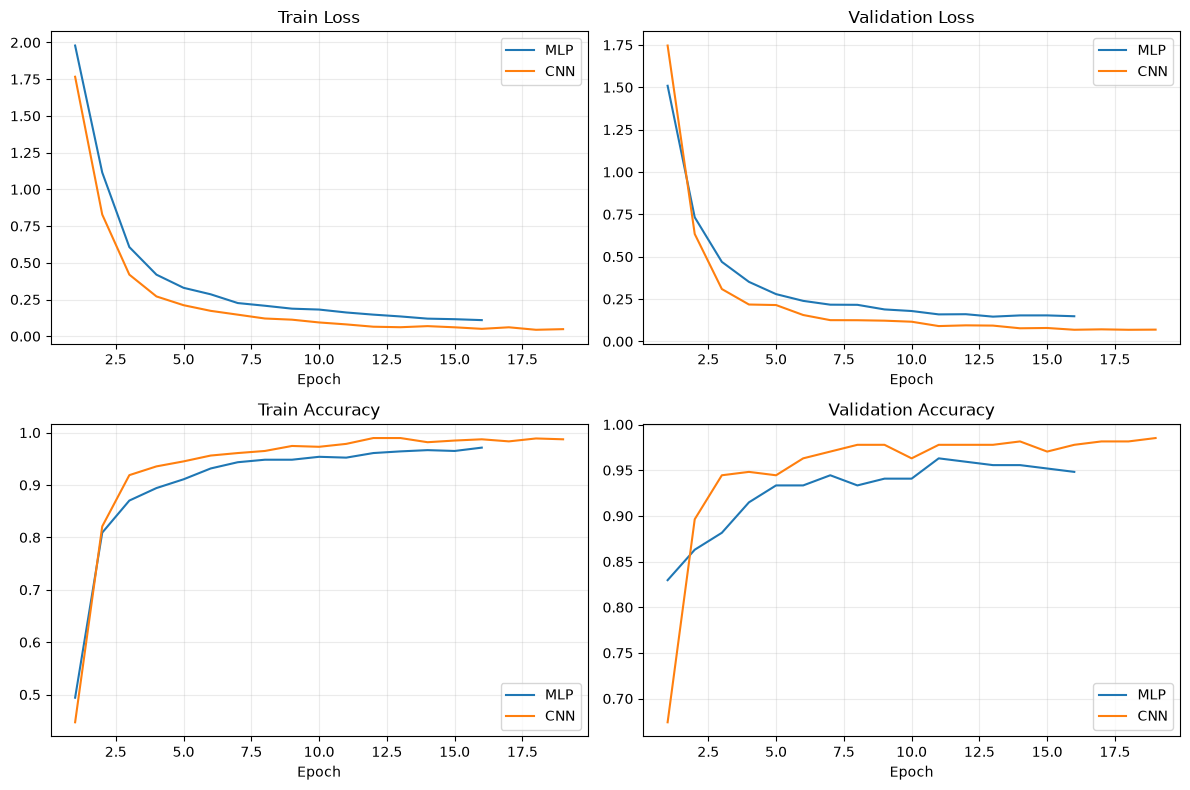

parameter: Parameter containing:
tensor([[ 0.0956, -0.2184, -0.4916,  ..., -0.0505, -0.0226, -0.4275],
        [ 0.0383, -0.0260,  0.1037,  ..., -0.0729, -0.0428, -0.0987],
        [ 0.1048,  0.2300,  0.2647,  ...,  0.2493,  0.1735,  0.2457],
        ...,
        [-0.0886,  0.2312,  0.1297,  ...,  0.4495,  0.3186,  0.3228],
        [-0.0823,  0.3937,  0.2446,  ..., -0.0034, -0.1126, -0.0190],
        [ 0.1050, -0.3919, -0.0954,  ..., -0.0513,  0.0339,  0.4560]],
       device='cuda:0', requires_grad=True)
parameter: Parameter containing:
tensor([ 0.0449,  0.1006,  0.0919,  0.1494,  0.0289,  0.1875, -0.1222,  0.0315,
         0.0277, -0.1036, -0.0849, -0.0740,  0.0608, -0.0500, -0.0576,  0.1695,
         0.0801,  0.0588,  0.0262,  0.1445,  0.1346,  0.0309, -0.0267,  0.0937,
         0.0969,  0.1269, -0.0362,  0.0857,  0.0561, -0.0674,  0.0154, -0.0290,
        -0.0665, -0.0225, -0.0131, -0.0506,  0.0602,  0.1898, -0.1190, -0.0962,
        -0.0190,  0.0290,  0.1635, -0.0858,  0.0853, -0.

In [9]:
# TODO-B3-CURVE: Early Stopping으로 길이가 달라질 수 있는 두 history를 연결합니다.
curve_series = {
    "mlp_train_loss": mlp_history["train_loss"],
    "mlp_valid_loss": mlp_history["valid_loss"],
    "mlp_train_accuracy": mlp_history["train_accuracy"],
    "mlp_valid_accuracy": mlp_history["valid_accuracy"],

    "cnn_train_loss": cnn_history["train_loss"],
    "cnn_valid_loss": cnn_history["valid_loss"],
    "cnn_train_accuracy": cnn_history["train_accuracy"],
    "cnn_valid_accuracy": cnn_history["valid_accuracy"],

    "mlp_epochs": np.arange(1, len(mlp_history["train_loss"]) + 1),
    "cnn_epochs": np.arange(1, len(cnn_history["train_loss"]) + 1)
}

# TODO("TODO-B3-CURVE: 모델별 epoch와 train/valid loss/accuracy를 dictionary로 연결")

for model_name in ("mlp", "cnn"):
    epoch_values = curve_series[f"{model_name}_epochs"]
    assert len(epoch_values) == len(
        curve_series[f"{model_name}_train_loss"]
    )
    assert len(epoch_values) == len(
        curve_series[f"{model_name}_valid_loss"]
    )
    assert len(epoch_values) == len(
        curve_series[f"{model_name}_train_accuracy"]
    )
    assert len(epoch_values) == len(
        curve_series[f"{model_name}_valid_accuracy"]
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for model_name, color in (("mlp", "tab:blue"), ("cnn", "tab:orange")):
    epoch_values = curve_series[f"{model_name}_epochs"]
    axes[0, 0].plot(
        epoch_values,
        curve_series[f"{model_name}_train_loss"],
        label=model_name.upper(),
        color=color,
    )
    axes[0, 1].plot(
        epoch_values,
        curve_series[f"{model_name}_valid_loss"],
        label=model_name.upper(),
        color=color,
    )
    axes[1, 0].plot(
        epoch_values,
        curve_series[f"{model_name}_train_accuracy"],
        label=model_name.upper(),
        color=color,
    )
    axes[1, 1].plot(
        epoch_values,
        curve_series[f"{model_name}_valid_accuracy"],
        label=model_name.upper(),
        color=color,
    )

axes[0, 0].set_title("Train Loss")
axes[0, 1].set_title("Validation Loss")
axes[1, 0].set_title("Train Accuracy")
axes[1, 1].set_title("Validation Accuracy")
for axis in axes.ravel():
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

comparison_report = {
    "shared_policy": {
        "split_fingerprint": split_fingerprint,
        "seed": SEED,
        "max_epochs": EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "loss": type(criterion).__name__,
        "optimizer_family": "Adam",
    },
    "MLP": {
        "parameters": count_trainable_parameters(fair_mlp),
        "epochs_run": mlp_training_summary["epochs_run"],
        "stopped_early": mlp_training_summary["stopped_early"],
        "best_epoch_by_min_valid_loss": mlp_training_summary["best_epoch"],
        "best_valid_loss": mlp_training_summary["best_valid_loss"],
        "valid_accuracy_at_best_loss": mlp_training_summary[
            "best_valid_accuracy_at_best_loss"
        ],
        "prediction_diversity": mlp_prediction_diversity,
    },
    "CNN": {
        "parameters": count_trainable_parameters(fair_cnn),
        "epochs_run": cnn_training_summary["epochs_run"],
        "stopped_early": cnn_training_summary["stopped_early"],
        "best_epoch_by_min_valid_loss": cnn_training_summary["best_epoch"],
        "best_valid_loss": cnn_training_summary["best_valid_loss"],
        "valid_accuracy_at_best_loss": cnn_training_summary[
            "best_valid_accuracy_at_best_loss"
        ],
        "prediction_diversity": cnn_prediction_diversity,
        "shape_trace": cnn_shape_trace,
    },
}
CORE_B3_PASS = True
print("문제 3 필수 자동 검증: PASS")
print(json.dumps(comparison_report, ensure_ascii=False, indent=2))
print(
    "동적 해설:",
    f"MLP/CNN의 min-validation-loss checkpoint accuracy는 각각 "
    f"{comparison_report['MLP']['valid_accuracy_at_best_loss']:.4f}/"
    f"{comparison_report['CNN']['valid_accuracy_at_best_loss']:.4f}이고, "
    f"실행 epoch는 {comparison_report['MLP']['epochs_run']}/"
    f"{comparison_report['CNN']['epochs_run']}입니다. "
    "동일한 최대 학습·Early Stopping 정책을 적용했지만 구조 전체가 다르므로 "
    "CNN 한 요소만의 인과 효과로 일반화하지 않습니다.",
)


### ✍️ 문제 3 필수 결과 해석 - 직접 작성

실제 비교 출력과 곡선을 근거로 5~7문장으로 작성하세요.

- 두 모델의 파라미터 수와 best validation metric
- train/validation 곡선에서 보인 정상 학습 또는 과적합 신호
- CNN shape 흐름과 이미지 공간 구조의 관계
- prediction diversity가 확인하는 것
- 특정 accuracy를 채점하지 않고 한 번의 결과를 일반화하지 않는 이유
- 다음 실험에서 바꿀 요소 하나와 그대로 유지할 조건

> **답안 작성 공간**  
> 두 모델의 파라미터 수는 MLP가 4810, CNN이 1946으로 CNN이 현저하게 작으며, 최저 loss의 epoch까지 MLP는 13, CNN은 18회이다. 그 때의 loss는 0.14609 / 0.06850으로 cnn이 우세하며 accuracy도 마찬가지로 95.56% / 98.15%로 cnn이 우세하다. train/validation 곡선에서 train accuracy가 올라가는데 반해, validation accuracy가 내려간다면 그것은 해당 학습 데이터에 대한 과적합 신호로 볼 수 있다. CNN shape는 Conv2d로 주변 픽셀을 함께 보고, Pool로 각 사이즈를 절반으로 줄인다. prediction diversity는 예측한 클래스 종류의 개수를 확인한다. 특정 accuracy를 채점하지 않고 한 번의 결과를 일반화 하지 않는 이유로는 해당 특정 시점에 대해서 과적합 되어 해당 시점만 잘 나오고 평균적으로 나머지 주변 시점에서는 별로 좋은 결과를 얻지 못하는 모델일 수 있으므로 해당 시점 하나만으로 일반화 하면 안되고, 다음 실험이 아래 5점 도전 B3라면, CNN의 Dropout만 제거하고 나머지 조건을 유지해 dropout이 미치는 영향 차이를 비교한다.


In [10]:
# 과제가 쉬웠다면 도전해보세요! - 5점 도전 B3
CHALLENGE_B3_DONE = True
CHALLENGE_B3_PASS = False

if CHALLENGE_B3_DONE:
    # TODO-B3-CHALLENGE:
    set_all_seeds(SEED)
    cnn_model_with_no_dropout = ImprovedCNN(dropout_rate=0.0).to(DEVICE)
    optimizer_no_dropout = torch.optim.Adam(cnn_model_with_no_dropout.parameters(), lr=LEARNING_RATE)

    hisory_no_dropout, records_no_dropout, summary_no_dropout = fit_model(
        cnn_model_with_no_dropout,
        optimizer_no_dropout,
        make_train_loader(SEED),
        valid_loader,
        EPOCHS,
    )



    # criterion_no_dropout = nn.CrossEntropyLoss()
    # optimizer_no_dropout.zero_grad()
    # logits_no_dropout = cnn_model_with_no_dropout(images_device)
    # loss_no_dropout = criterion(logits_no_dropout, labels_device)
    # loss_no_dropout.backward()

    # ImprovedCNN(dropout_rate=0.0)을 같은 seed/split/epoch/lr로 학습하고
    # 바뀐 변수·고정 조건·두 best validation metric을 report로 만드세요.

    ablation_report = {
        "changed_variable": "dropout_rate: 0.2 >> 0.0",
        "baseline_best_valid_loss": cnn_training_summary["best_valid_loss"],
        "no_dropout_best_valid_loss": summary_no_dropout["best_valid_loss"],
        "baseline_best_valid_accuracy": cnn_training_summary["best_valid_accuracy_at_best_loss"],
        "no_dropout_best_valid_accuracy": summary_no_dropout["best_valid_accuracy_at_best_loss"],
        "fixed_conditions": {
            "seed": SEED,
            "split": "동일한 train/validation 데이터",
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "max_epochs": EPOCHS,
            "patience": EARLY_STOPPING_PATIENCE,
            "min_delta": EARLY_STOPPING_MIN_DELTA,
        },
    }

    print(ablation_report)

else:
    print("5점 도전 B3: SKIPPED - 필수 점수 감점 없음")


epoch=01 train_loss=1.6944 train_acc=0.5386 valid_loss=1.7080 valid_acc=0.7074 early_stop_wait=0/3
epoch=02 train_loss=0.6588 train_acc=0.9085 valid_loss=0.5439 valid_acc=0.9148 early_stop_wait=0/3
epoch=03 train_loss=0.2772 train_acc=0.9594 valid_loss=0.2554 valid_acc=0.9444 early_stop_wait=0/3
epoch=04 train_loss=0.1512 train_acc=0.9753 valid_loss=0.1825 valid_acc=0.9630 early_stop_wait=0/3
epoch=05 train_loss=0.1041 train_acc=0.9881 valid_loss=0.1480 valid_acc=0.9630 early_stop_wait=0/3
epoch=06 train_loss=0.0720 train_acc=0.9920 valid_loss=0.1137 valid_acc=0.9667 early_stop_wait=0/3
epoch=07 train_loss=0.0522 train_acc=0.9968 valid_loss=0.1029 valid_acc=0.9667 early_stop_wait=0/3
epoch=08 train_loss=0.0439 train_acc=0.9960 valid_loss=0.0932 valid_acc=0.9741 early_stop_wait=0/3
epoch=09 train_loss=0.0368 train_acc=0.9984 valid_loss=0.0875 valid_acc=0.9741 early_stop_wait=0/3
epoch=10 train_loss=0.0269 train_acc=0.9968 valid_loss=0.0781 valid_acc=0.9704 early_stop_wait=0/3
epoch=11 t

### 🚀 5점 도전 B3 결과 해석 - 수행한 경우 작성

1. baseline CNN과 Dropout 제거 CNN의 실제 best validation metric을 기록하세요.
2. 두 실험에서 고정한 조건과 바꾼 조건 하나를 구분하여 작성하세요.
3. 한 번의 seed 결과만으로 Dropout의 일반적인 효과를 단정할 수 없는 이유를 포함해
   3~4문장으로 해석하세요.

> **답안 작성 공간**  
> Dropout 제거 후 validation loss(best)는 낮아졌고, accuracy는 둘 다 약 98.15%이다.
> 바꾼 조건은 cnn의 모델의 dropout유무이고, 나머지 조건은 모두 고정했다.
> 한 시드에서 수행한 결과 dropout 제거가 오히려 validation loss가 낮아져서 유리하다고 결론내릴 수 없다. 초기 가중치나 학습 순서, 데이터 분할이 달라지면 결과가 달라질 수 있기 때문에, 많은 환경에서 테스트를 해야 한다.


# 4. 💾 Best checkpoint 저장·복원·학습 재개

## 문제 배경

학습이 끝난 메모리 속 모델은 런타임이 종료되면 사라집니다. 모델 weight뿐 아니라
optimizer·epoch·설정·학습 이력까지 함께 저장해야 중단된 실험을 믿고 이어갈 수 있습니다.

## 이 문제에서 배우는 것

- 마지막 epoch와 validation-best epoch의 차이
- 평가·추론용 best checkpoint와 중단 지점 재개용 last checkpoint의 차이
- model·optimizer `state_dict`를 함께 저장하는 이유
- 새 모델에서 복원 전후 logits·class를 비교하는 방법
- `start_epoch`와 optimizer 상태를 이용한 학습 재개

## 수행 순서

1. validation loss가 가장 낮은 CNN epoch를 선택합니다.
2. best checkpoint에는 best model과 metric을, last checkpoint에는 마지막 model·optimizer·epoch를 저장합니다.
3. 저장 직전 validation logits를 보관합니다.
4. 새 CNN에 best checkpoint를 복원해 logits 허용오차와 class 완전 일치를 확인합니다.
5. 별도의 새 CNN·optimizer에 last checkpoint를 복원합니다.
6. 마지막 epoch 다음의 `start_epoch`를 계산하고 한 batch를 추가 학습합니다.
7. resume loss가 finite이고 파라미터가 실제로 업데이트되는지 검사합니다.

## 제출 결과물

- best·last epoch, validation loss와 두 checkpoint의 key
- reload logits 최대 차이·class 일치
- start epoch·resume loss·파라미터 업데이트
- `문제 4 필수 자동 검증: PASS`

## ⚠️ 자주 발생하는 실수

- 마지막 epoch 모델을 자동으로 best 모델이라고 간주하기
- 학습 재개용 파일에서 optimizer 상태나 epoch를 빼기
- checkpoint 호환성을 확인하기 전에 model state를 적용하기
- test metric을 확인한 뒤 모델 선택을 다시 시작하기

## 🚀 5점 도전 미리보기

schema·입력 shape·class 수·source/split fingerprint가 현재 실험과 맞는지 load 전에
검사하는 호환성 guard를 만듭니다.


In [11]:
# TODO-B4-BEST: validation loss가 가장 작은 epoch index를 선택합니다.
best_cnn_index = np.argmin(cnn_history["valid_loss"])
# TODO("TODO-B4-BEST: validation loss가 가장 작은 index")

best_cnn_record = cnn_records[best_cnn_index]
best_cnn_epoch = int(best_cnn_record["epoch"])
best_cnn_valid_loss = float(best_cnn_record["valid_loss"])
best_cnn_valid_accuracy = float(best_cnn_record["valid_accuracy"])
last_cnn_record = cnn_training_summary["last_record"]
last_cnn_epoch = int(last_cnn_record["epoch"])
assert best_cnn_epoch == cnn_training_summary["best_epoch"]
assert last_cnn_epoch == cnn_training_summary["last_epoch"]
assert np.isclose(best_cnn_valid_loss, min(cnn_history["valid_loss"]))

# 저장 직전 기준 logits는 in-memory best state로 계산합니다.
pre_save_model = ImprovedCNN().to(DEVICE)
pre_save_model.load_state_dict(best_cnn_record["model_state_dict"])
pre_save_model.eval()
reload_probe_images, _ = next(iter(valid_loader))
reload_probe_images_device = reload_probe_images.to(DEVICE)
with torch.no_grad():
    pre_save_logits = pre_save_model(reload_probe_images_device)

common_config = {
    "model_class": "ImprovedCNN",
    "input_shape": [1, 8, 8],
    "num_classes": NUM_CLASSES,
    "dropout_rate": DROPOUT_RATE,
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "max_epochs": EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
}


# best는 평가·추론용입니다. optimizer는 last와 섞지 않습니다.
best_checkpoint = {
    "checkpoint_role": "best_for_inference",
    "model_state_dict": best_cnn_record["model_state_dict"],
    #  TODO("TODO-B4-CHECKPOINT: best model_state_dict")
    "epoch": best_cnn_epoch,
    "best_valid_loss": best_cnn_valid_loss,
    "best_valid_accuracy": best_cnn_valid_accuracy,
    "history": copy.deepcopy(cnn_history),
    "config": copy.deepcopy(common_config),
}

# last는 중단 지점 다음 epoch부터 학습을 이어가기 위한 기록입니다.
last_checkpoint = {
    "checkpoint_role": "last_for_resume",
    "model_state_dict": copy.deepcopy(
        last_cnn_record["model_state_dict"]
    ),
    "optimizer_state_dict": copy.deepcopy(
        last_cnn_record["optimizer_state_dict"]
    ),
    # TODO("TODO-B4-LAST-CHECKPOINT: last optimizer_state_dict"),
    "epoch": last_cnn_epoch,
    "last_valid_loss": float(last_cnn_record["valid_loss"]),
    "history": copy.deepcopy(cnn_history),
    "config": copy.deepcopy(common_config),
}

assert {
    "checkpoint_role", "model_state_dict", "epoch",
    "best_valid_loss", "history", "config",
} <= set(best_checkpoint)
assert {
    "checkpoint_role", "model_state_dict", "optimizer_state_dict",
    "epoch", "last_valid_loss", "history", "config",
} <= set(last_checkpoint)
assert best_checkpoint["checkpoint_role"] == "best_for_inference"
assert last_checkpoint["checkpoint_role"] == "last_for_resume"

checkpoint_dir = Path("assignment_outputs") / "basic_friendly_v3"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_checkpoint_path = checkpoint_dir / "best_cnn_checkpoint.pt"
last_checkpoint_path = checkpoint_dir / "last_cnn_checkpoint.pt"
# TODO-B4-SAVE: 용도가 다른 두 dictionary checkpoint를 각각 저장합니다.
# TODO("TODO-B4-SAVE: best와 last checkpoint를 각각 torch.save")
torch.save(best_checkpoint, best_checkpoint_path)
torch.save(last_checkpoint, last_checkpoint_path)

assert best_checkpoint_path.exists() and last_checkpoint_path.exists()

load_kwargs = {"map_location": "cpu"}
if "weights_only" in inspect.signature(torch.load).parameters:
    load_kwargs["weights_only"] = False # type: ignore
loaded_best_checkpoint = torch.load(best_checkpoint_path, **load_kwargs) # type: ignore
loaded_last_checkpoint = torch.load(last_checkpoint_path, **load_kwargs) # type: ignore

# best checkpoint는 새 모델의 평가·추론 상태를 복원합니다.
restored_model = ImprovedCNN().to(DEVICE)
# TODO-B4-LOAD-MODEL
restored_model.load_state_dict(
    loaded_best_checkpoint["model_state_dict"]
)
# TODO("TODO-B4-LOAD-MODEL: best model state를 새 모델에 복원")
restored_model.eval()
with torch.no_grad():
    restored_logits = restored_model(reload_probe_images_device)

torch.testing.assert_close(
    pre_save_logits, restored_logits, rtol=1e-5, atol=1e-6
)
assert torch.equal(
    pre_save_logits.argmax(dim=1), restored_logits.argmax(dim=1)
)

# last checkpoint는 별도 CPU model·optimizer에서 중단 지점 재개를 확인합니다.
resume_model = ImprovedCNN().cpu()
resume_optimizer = torch.optim.Adam(
    resume_model.parameters(), lr=LEARNING_RATE
)

# TODO-B4-LOAD-LAST-MODEL / TODO-B4-LOAD-OPT

# TODO("TODO-B4-LOAD-LAST-MODEL: last model state 복원")
resume_model.load_state_dict(
    loaded_last_checkpoint["model_state_dict"]
)

# TODO("TODO-B4-LOAD-OPT: last optimizer state 복원")
resume_optimizer.load_state_dict(
    loaded_last_checkpoint["optimizer_state_dict"]
)

# TODO-B4-START: 마지막으로 완료한 epoch 다음 번호입니다.

start_epoch = loaded_last_checkpoint["epoch"] + 1
# TODO("TODO-B4-START: last epoch 다음 번호")

assert start_epoch == last_cnn_epoch + 1
assert resume_optimizer.state_dict()["state"]

# 선택 심화 실행 여부와 무관한 필수 resume 결과를 위해 난수를 다시 고정합니다.
set_all_seeds(SEED)
resume_images, resume_labels = next(iter(make_train_loader(SEED)))
before_resume_parameters = [
    parameter.detach().clone() for parameter in resume_model.parameters()
]
resume_model.train()
resume_optimizer.zero_grad(set_to_none=True)
# TODO-B4-RESUME: 제공된 순서에서 forward를 완성합니다.
# TODO("TODO-B4-RESUME: resume batch forward")

resume_logits = resume_model(resume_images)

resume_loss = criterion(resume_logits, resume_labels.cpu())
resume_loss.backward()
resume_optimizer.step()
after_resume_parameters = [
    parameter.detach() for parameter in resume_model.parameters()
]
resumed_parameter_update = any(
    not torch.equal(before, after)
    for before, after in zip(
        before_resume_parameters, after_resume_parameters
    )
)
assert resumed_parameter_update is True
assert torch.isfinite(resume_loss)

CHECKPOINT_SUMMARY = {
    "best_checkpoint_role": best_checkpoint["checkpoint_role"],
    "best_checkpoint_keys": sorted(best_checkpoint.keys()),
    "best_epoch": best_cnn_epoch,
    "best_valid_loss": best_cnn_valid_loss,
    "best_valid_accuracy": best_cnn_valid_accuracy,
    "last_checkpoint_role": last_checkpoint["checkpoint_role"],
    "last_checkpoint_keys": sorted(last_checkpoint.keys()),
    "last_epoch": last_cnn_epoch,
    "last_valid_loss": cnn_training_summary["last_valid_loss"],
    "start_epoch": start_epoch,
    "reload_max_abs_gap": float(
        (pre_save_logits - restored_logits).abs().max().cpu()
    ),
    "reload_class_exact": bool(
        torch.equal(
            pre_save_logits.argmax(dim=1),
            restored_logits.argmax(dim=1),
        )
    ),
    "resume_loss": float(resume_loss.detach().cpu()),
    "resume_parameter_update": resumed_parameter_update,
}
print("문제 4 best·last checkpoint·reload·resume 검증: PASS")
print(json.dumps(CHECKPOINT_SUMMARY, ensure_ascii=False, indent=2))


문제 4 best·last checkpoint·reload·resume 검증: PASS
{
  "best_checkpoint_role": "best_for_inference",
  "best_checkpoint_keys": [
    "best_valid_accuracy",
    "best_valid_loss",
    "checkpoint_role",
    "config",
    "epoch",
    "history",
    "model_state_dict"
  ],
  "best_epoch": 18,
  "best_valid_loss": 0.06849700967194858,
  "best_valid_accuracy": 0.9814814814814815,
  "last_checkpoint_role": "last_for_resume",
  "last_checkpoint_keys": [
    "checkpoint_role",
    "config",
    "epoch",
    "history",
    "last_valid_loss",
    "model_state_dict",
    "optimizer_state_dict"
  ],
  "last_epoch": 19,
  "last_valid_loss": 0.06943074630366432,
  "start_epoch": 20,
  "reload_max_abs_gap": 0.0,
  "reload_class_exact": true,
  "resume_loss": 0.06776224821805954,
  "resume_parameter_update": true
}


### ✍️ 문제 4 필수 결과 해석 - 직접 작성

실제 출력값을 인용하여 4~5문장으로 설명하세요.

- best epoch·last epoch와 validation loss
- reload logits 최대 차이와 class 일치 여부
- 복원된 start epoch
- resume loss와 파라미터 업데이트 여부
- optimizer 상태까지 복원해야 하는 이유

> **답안 작성 공간**  
  - best_epoch는 18, last epoch는 19, best_validation_loss는 0.06849700967194858, last_valid_loss는  0.06943074630366432
  - reload logits 최대 차이는 0.0이고, class는 일치한다.
  - 복원된 start epoch는 20
  - resume loss는 0.06776224821805954 / 파라미터 업데이트 O
  - Adam은 과거 gradient의 이동편균과 제곱값의 이동평균, 업데이트 횟수를 저장하므로, 이전 학습의 업데이트 흐름을 이어가려면 모델 가중치뿐 아니라 opptimizer 상태도 복원해야 한다.


In [12]:
# 과제가 쉬웠다면 도전해보세요! - 5점 도전 B4
CHALLENGE_B4_DONE = True
CHALLENGE_B4_PASS = False

# schema와 fingerprint는 기초 필수가 아니라 호환성 guard 도전에서 추가합니다.
guarded_checkpoint = copy.deepcopy(best_checkpoint)
guarded_checkpoint.update(
    {
        "schema_version": 2,
        "source_fingerprint": source_fingerprint,
        "split_fingerprint": split_fingerprint,
    }
)

def validate_checkpoint_compatibility(
    candidate,
    expected_config,
    expected_source_fingerprint,
    expected_split_fingerprint,
):
    if not CHALLENGE_B4_DONE:
        return {}
    # TODO-B4-CHALLENGE:
    # required key, schema_version=2, config, 두 fingerprint를 검사하고
    # 모든 불일치 항목을 포함한 ValueError를 발생시키세요.

    lst = []

    if "schema_version" not in candidate:
        lst.append("missing schema_version")
    elif candidate["schema_version"] != 2:
        lst.append("mismatched schema_version")

    if "config" not in candidate:
        lst.append("missing config")
    else:
        for key in expected_config:
            if key not in candidate["config"]:
                lst.append(f"missing config.{key}")
            elif expected_config[key] != candidate["config"][key]:
                lst.append(f"mismatched config.{key}")

    if "source_fingerprint" not in candidate:
        lst.append("missing source_fingerprint")
    elif candidate["source_fingerprint"] != expected_source_fingerprint:
        lst.append("mismatched source_fingerprint")


    if "split_fingerprint" not in candidate:
        lst.append("missing split_fingerprint")
    elif candidate["split_fingerprint"] != expected_split_fingerprint:
        lst.append("mismatched split_fingerprint")

    print(f"candidate: {candidate.keys()}")
    print(f"expected_config.keys(): {expected_config.keys()}")

    if lst:
        raise ValueError(lst)

    return {"compatible": True}

if CHALLENGE_B4_DONE:
    expected_checkpoint_config = {
        "model_class": "ImprovedCNN",
        "input_shape": [1, 8, 8],
        "num_classes": NUM_CLASSES,
        "dropout_rate": DROPOUT_RATE,
    }
    # guard를 먼저 통과한 뒤에만 별도의 새 모델에 state를 적용합니다.
    compatibility_report = validate_checkpoint_compatibility(
        guarded_checkpoint,
        expected_checkpoint_config,
        source_fingerprint,
        split_fingerprint,
    )
    guard_probe_model = ImprovedCNN().cpu()
    guard_probe_model.load_state_dict(
        guarded_checkpoint["model_state_dict"]
    )
    deliberately_mismatched = copy.deepcopy(guarded_checkpoint)
    deliberately_mismatched["config"]["input_shape"] = [1, 28, 28]
    mismatch_detected = False
    mismatch_message = ""
    try:
        validate_checkpoint_compatibility(
            deliberately_mismatched,
            expected_checkpoint_config,
            source_fingerprint,
            split_fingerprint,
        )
    except ValueError as error:
        mismatch_detected = True
        mismatch_message = str(error)
    assert mismatch_detected is True
    assert "config.input_shape" in mismatch_message
    CHALLENGE_B4_PASS = True
    print(
        "5점 도전 B4 자동 검증: PASS",
        {
            "compatible": compatibility_report,
            "mismatch": mismatch_message,
            "guard_before_load": True,
        },
    )

    print(f"compatibility_report: {compatibility_report}")
else:
    print("5점 도전 B4: SKIPPED - 필수 점수 감점 없음")


candidate: dict_keys(['checkpoint_role', 'model_state_dict', 'epoch', 'best_valid_loss', 'best_valid_accuracy', 'history', 'config', 'schema_version', 'source_fingerprint', 'split_fingerprint'])
expected_config.keys(): dict_keys(['model_class', 'input_shape', 'num_classes', 'dropout_rate'])
candidate: dict_keys(['checkpoint_role', 'model_state_dict', 'epoch', 'best_valid_loss', 'best_valid_accuracy', 'history', 'config', 'schema_version', 'source_fingerprint', 'split_fingerprint'])
expected_config.keys(): dict_keys(['model_class', 'input_shape', 'num_classes', 'dropout_rate'])
5점 도전 B4 자동 검증: PASS {'compatible': {'compatible': True}, 'mismatch': "['mismatched config.input_shape']", 'guard_before_load': True}
compatibility_report: {'compatible': True}


### 🚀 5점 도전 B4 결과 해석 - 수행한 경우 작성

1. 정상 checkpoint의 compatibility report를 기록하세요.
2. 입력 shape를 28×28로 바꾼 checkpoint가 낸 실제 오류 메시지를 기록하세요.
3. load 전에 호환성을 검사하면 어떤 잘못된 실험 재사용을 예방할 수 있는지 3문장으로 설명하세요.

> **답안 작성 공간**  
> 1.  True 반환
> 2.  "['mismatched config.input_shape']"
> 3.  설정이 현재 실험과 일치하는지 확인한다. source와 split fingerprint를 비교하면 다른 원본 데이터나 데이터 분할에서 학습한 체크포인트를 잘못 재사용 하는것을 예방할 수 있다. 불일치가 있으면 복원을 중단하므로 잘못된 조건으로 평가하거나 학습을 재개하는 일을 막을 수 있다.


# 🧪 최종 test - 이 단계에서만 DataLoader 생성

validation으로 모델 구조·epoch·checkpoint를 모두 확정한 뒤 예약해 둔 test index를
처음 사용합니다. 이 단계에서는 test DataLoader를 한 번 만들고 validation-best 모델을
한 번 평가합니다.

> 🔒 test 결과를 본 뒤 모델·epoch·Dropout·learning rate를 다시 고르면 test가 사실상
> validation 역할을 하게 됩니다. 그러면 일반화 성능을 독립적으로 확인할 수 없습니다.

## 확인할 결과

- test loader 생성 횟수: 1
- test 전체 평가 횟수: 1
- test loss·accuracy·prediction diversity
- 처음 10개 정답과 예측


In [13]:
TEST_LOADER_CREATION_CALLS = 0
TEST_EVALUATION_CALLS = 0

def build_final_test_loader():
    global TEST_LOADER_CREATION_CALLS
    if TEST_LOADER_CREATION_CALLS != 0:
        raise RuntimeError("test DataLoader는 최종 단계에서 한 번만 생성합니다.")
    TEST_LOADER_CREATION_CALLS += 1
    final_test_dataset = TensorDataset(
        images_all[final_test_indices],
        labels_all[final_test_indices],
    )
    return DataLoader(
        final_test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )


def evaluate_test_once(model, data_loader, loss_fn, device):
    global TEST_EVALUATION_CALLS
    if TEST_EVALUATION_CALLS != 0:
        raise RuntimeError("전체 test 평가는 한 번만 허용됩니다.")
    TEST_EVALUATION_CALLS += 1
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_truth = []
    all_predictions = []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = loss_fn(logits, labels)
            # TODO-B4-INFERENCE: raw logits에서 가장 큰 class index를 선택합니다.
            predictions = logits.argmax(dim=-1)
            # TODO("TODO-B4-INFERENCE: logits에서 class ID 선택")
            batch_size = len(labels)
            total_loss += float(loss.cpu()) * batch_size
            total_correct += int(
                (predictions == labels).sum().item()
            )
            total_samples += batch_size
            all_truth.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())
    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "samples": total_samples,
        "truth": all_truth,
        "predictions": all_predictions,
    }


final_test_loader = build_final_test_loader()
test_result = evaluate_test_once(
    restored_model, final_test_loader, criterion, DEVICE
)
assert TEST_LOADER_CREATION_CALLS == 1
assert TEST_EVALUATION_CALLS == 1
assert test_result["samples"] == len(final_test_indices)
assert np.isfinite(test_result["loss"])
assert np.isfinite(test_result["accuracy"])
assert len(set(test_result["predictions"])) >= 2

prediction_pairs_preview = [
    {"truth": truth, "prediction": prediction}
    for truth, prediction in zip(
        test_result["truth"][:10],
        test_result["predictions"][:10],
    )
]
test_prediction_hash = hashlib.sha256(
    np.asarray(test_result["predictions"], dtype=np.int64).tobytes()
).hexdigest()

CORE_B4_PASS = True
print("문제 4 필수 자동 검증: PASS")
print(
    json.dumps(
        {
            "best_epoch": best_cnn_epoch,
            "last_epoch": last_cnn_epoch,
            "best_valid_loss": best_cnn_valid_loss,
            "test_loss": test_result["loss"],
            "test_accuracy": test_result["accuracy"],
            "test_samples": test_result["samples"],
            "prediction_diversity": len(
                set(test_result["predictions"])
            ),
            "truth_prediction_preview": prediction_pairs_preview,
            "prediction_hash": test_prediction_hash,
        },
        ensure_ascii=False,
        indent=2,
    )
)
print(
    "동적 해설:",
    f"validation loss로 선택한 epoch {best_cnn_epoch}의 best 모델을 "
    f"test {test_result['samples']}개에 한 번 적용해 "
    f"loss={test_result['loss']:.4f}, "
    f"accuracy={test_result['accuracy']:.4f}를 얻었습니다. "
    "이 값은 고정 split 한 번의 결과이며 다른 이미지 도메인으로 "
    "일반화하지 않습니다.",
)


문제 4 필수 자동 검증: PASS
{
  "best_epoch": 18,
  "last_epoch": 19,
  "best_valid_loss": 0.06849700967194858,
  "test_loss": 0.08031617466498304,
  "test_accuracy": 0.9666666666666667,
  "test_samples": 270,
  "prediction_diversity": 10,
  "truth_prediction_preview": [
    {
      "truth": 8,
      "prediction": 8
    },
    {
      "truth": 1,
      "prediction": 1
    },
    {
      "truth": 6,
      "prediction": 6
    },
    {
      "truth": 4,
      "prediction": 4
    },
    {
      "truth": 5,
      "prediction": 5
    },
    {
      "truth": 0,
      "prediction": 0
    },
    {
      "truth": 1,
      "prediction": 1
    },
    {
      "truth": 4,
      "prediction": 4
    },
    {
      "truth": 9,
      "prediction": 9
    },
    {
      "truth": 2,
      "prediction": 2
    }
  ],
  "prediction_hash": "3886c6e3b1c6b7337f9b2a0feb46daa471226aaaaeab2d4052f12036a9521124"
}
동적 해설: validation loss로 선택한 epoch 18의 best 모델을 test 270개에 한 번 적용해 loss=0.0803, accuracy=0.9667를 얻었습니다. 이 값은 고정 s

### ✍️ 최종 test 결과 해석 - 직접 작성

실제 best epoch·validation loss·test loss·test accuracy·prediction diversity를 인용하고,
test를 한 번만 평가한 이유와 작은 고정 split 결과의 한계를 4문장 이내로 작성하세요.

> **답안 작성 공간**  
>  best epoch는 18이고, validation loss는 0.06850으로 제일 낮았다. test loss는 0.08032이고, test accuracy는 96.67%이다. prediction diversity는 10으로 예측 결과에 모든 클래스가 등장했다. test는 학습이 아닌 평가하는 단계이므로 테스트 결과로 모델을 튜닝하거나 하면 안되기에 한번만 평가한다. 작은 고정 split의 분할에서 얻은 데이터는 실제 많은 케이스를 다 커버하지 못하므로 엣지 케이스에서 성능이 떨어질 수 있는 한계가 있다.


# ✅ 최종 자동 검증

이 셀은 문제 1~4의 필수 상태와 선택 심화 상태를 따로 보여 줍니다.

- 필수 B1~B4는 모두 `PASS`여야 제출할 수 있습니다.
- 선택 심화를 하지 않았다면 `SKIPPED`가 정상입니다.
- 선택 심화 `SKIPPED`는 필수 점수를 깎지 않습니다.
- 실행 결과에 `FINAL REQUIRED STATUS: PASS`가 표시되는지 확인하세요.


In [14]:
required_checks = {
    "B1": CORE_B1_PASS,
    "B2": CORE_B2_PASS,
    "B3": CORE_B3_PASS,
    "B4": CORE_B4_PASS,
}
challenge_status = {
    "B1": "PASS" if CHALLENGE_B1_PASS else "SKIPPED",
    "B2": "PASS" if CHALLENGE_B2_PASS else "SKIPPED",
    "B3": "PASS" if CHALLENGE_B3_PASS else "SKIPPED",
    "B4": "PASS" if CHALLENGE_B4_PASS else "SKIPPED",
}
assert all(required_checks.values())

RUN_SUMMARY = {
    "course": "딥러닝_기초",
    "revision": "friendly_v3",
    "device": str(DEVICE),
    "todo_ids": TODO_IDS,
    "source_fingerprint": source_fingerprint,
    "split_fingerprint": split_fingerprint,
    "parameters": {
        "MLP": count_trainable_parameters(fair_mlp),
        "CNN": count_trainable_parameters(fair_cnn),
    },
    "evidence": {
        "split_sizes": SPLIT_SUMMARY,
        "problem_1": PROBLEM_1_EVIDENCE,
        "normalized_pixel_range": [
            float(images_all.min()),
            float(images_all.max()),
        ],
        "batch_contract": batch_contract_report,
        "cnn_shape_trace": cnn_shape_trace,
        "mode_gaps": {
            "train_dropout_gap": train_repeat_gap,
            "bn_running_delta": bn_running_delta,
            "eval_repeat_gap": eval_repeat_gap,
        },
        "mlp_training": {
            key: value
            for key, value in mlp_training_summary.items()
            if key not in {"best_record", "last_record"}
        },
        "cnn_training": {
            key: value
            for key, value in cnn_training_summary.items()
            if key not in {"best_record", "last_record"}
        },
        "comparison": comparison_report,
        "checkpoint": CHECKPOINT_SUMMARY,
        "challenge_b1_errors": globals().get("detected_errors"),
        "challenge_b2_hook_shapes": globals().get("hook_shape_trace"),
        "challenge_b2_manual_parameters": globals().get(
            "manual_cnn_parameter_budget"
        ),
        "challenge_b3_ablation": globals().get("ablation_report"),
        "challenge_b4_compatibility": globals().get(
            "compatibility_report"
        ),
        "challenge_b4_mismatch": globals().get("mismatch_message"),
        "test_truth_prediction_preview": prediction_pairs_preview,
    },
    "cnn_epochs_run": cnn_training_summary["epochs_run"],
    "cnn_stopped_early": cnn_training_summary["stopped_early"],
    "best_epoch": best_cnn_epoch,
    "last_epoch": last_cnn_epoch,
    "best_valid_loss": best_cnn_valid_loss,
    "best_valid_accuracy": best_cnn_valid_accuracy,
    "test_loss": float(test_result["loss"]),
    "test_accuracy": float(test_result["accuracy"]),
    "test_prediction_diversity": len(
        set(test_result["predictions"])
    ),
    "test_prediction_hash": test_prediction_hash,
    "test_prediction_preview": test_result["predictions"][:10],
    "reload_logits": restored_logits[:2].detach().cpu().tolist(),
    "test_loader_creation_calls": TEST_LOADER_CREATION_CALLS,
    "test_evaluation_calls": TEST_EVALUATION_CALLS,
    "required": required_checks,
    "challenges": challenge_status,
}
print("FINAL REQUIRED STATUS: PASS")
print(
    "5점 도전:",
    f"{sum(value == 'PASS' for value in challenge_status.values())}/4",
    challenge_status,
)
print(
    "RUN_SUMMARY_JSON="
    + json.dumps(RUN_SUMMARY, ensure_ascii=False)
)


parameter: Parameter containing:
tensor([[ 0.0956, -0.2184, -0.4916,  ..., -0.0505, -0.0226, -0.4275],
        [ 0.0383, -0.0260,  0.1037,  ..., -0.0729, -0.0428, -0.0987],
        [ 0.1048,  0.2300,  0.2647,  ...,  0.2493,  0.1735,  0.2457],
        ...,
        [-0.0886,  0.2312,  0.1297,  ...,  0.4495,  0.3186,  0.3228],
        [-0.0823,  0.3937,  0.2446,  ..., -0.0034, -0.1126, -0.0190],
        [ 0.1050, -0.3919, -0.0954,  ..., -0.0513,  0.0339,  0.4560]],
       device='cuda:0', requires_grad=True)
parameter: Parameter containing:
tensor([ 0.0449,  0.1006,  0.0919,  0.1494,  0.0289,  0.1875, -0.1222,  0.0315,
         0.0277, -0.1036, -0.0849, -0.0740,  0.0608, -0.0500, -0.0576,  0.1695,
         0.0801,  0.0588,  0.0262,  0.1445,  0.1346,  0.0309, -0.0267,  0.0937,
         0.0969,  0.1269, -0.0362,  0.0857,  0.0561, -0.0674,  0.0154, -0.0290,
        -0.0665, -0.0225, -0.0131, -0.0506,  0.0602,  0.1898, -0.1190, -0.0962,
        -0.0190,  0.0290,  0.1635, -0.0858,  0.0853, -0.

# 🎓 마무리
## 제출 전에 마지막으로 확인하세요

- MLP-CNN 비교, 네 개 학습 곡선, shape 흐름, 파라미터 수, 비교 리포트가 모두 있나요?
- 설명 답안이 “좋았다·나빴다”가 아니라 실제 출력값을 근거로 작성되었나요?
- test 결과를 모델 선택에 사용하지 않았나요?
- 새 런타임에서 위에서부터 모두 실행했나요?

수고하셨습니다. 이 과제를 끝까지 완성했다면 하나의 작은 딥러닝 실험을 준비하고,
학습하고, 검증하고, 저장하고, 다시 사용하는 전체 흐름을 경험한 것입니다. 🙌


## AI 활용 내역

본 과제에서는 OpenAI 대화형 AI를 활용하여 문제 요구사항과 Tensor·모델의 동작을 이해하고, 구현 중 막힌 부분과 실행 오류를 해결했다. 개념 설명과 코드 검토뿐 아니라 일부 TODO의 구체적인 코드 예시, 결과 해석의 문장 예시도 제공받아 참고했다.

- **데이터 준비와 배치 검증:** train/validation/test 분할과 seed의 역할, DataLoader 설정, NHWC에서 NCHW로의 변환, dtype·device·유한값·label 범위 검사의 의미와 구현을 안내받았다. 배치 계약 검사와 선택 심화의 오류 수집 코드도 검토받았다.
- **MLP와 CNN 구성:** `ImageMLP`와 `ImprovedCNN`의 구성, convolution·BatchNorm·ReLU·pooling·Dropout·flatten·classifier의 역할 및 단계별 shape을 설명받았다. logits 계산, 학습 가능한 파라미터 수와 bias 계산, hook을 이용한 shape 수집 구현에도 도움을 받았다.
- **학습·검증과 비교 실험:** 학습 루프의 loss·gradient·optimizer 처리, 배치 크기를 반영한 평균 loss와 accuracy 계산, `train()`·`eval()`·`no_grad()`의 차이를 질문했다. Dropout과 BatchNorm으로 인한 반복 출력 차이, Early Stopping과 best epoch의 구분, 학습 곡선 및 MLP-CNN 비교 해석을 검토받았다.
- **Dropout 제거 심화:** 기존 `fit_model`을 재사용해 Dropout만 제거한 CNN을 같은 조건에서 학습하는 방법을 안내받았다. `ablation_report`에 두 실험의 best validation loss와 해당 시점의 accuracy, 고정 조건을 기록하는 코드 예시를 제공받았으며, 한 seed의 결과를 일반화할 수 없는 이유와 보고서 문장을 검토받았다.
- **체크포인트 저장·복원:** best와 last 기록의 차이, `state_dict`, Adam 상태를 함께 저장하는 이유를 설명받았다. best epoch 선택, `torch.save`와 `torch.load`, `load_state_dict`의 사용법 및 잘못된 복원 호출의 오류를 안내받았고, 복원 결과와 학습 재개 결과의 해석을 검토받았다.
- **호환성 검사 심화:** schema·config·source/split fingerprint 검사, 누락된 key와 불일치를 모아 `ValueError`로 알리는 방식, 정상 보고서 반환에 대해 코드 예시와 피드백을 받았다. 제공된 검증이 통과하더라도 required key 검사가 모두 구현됐다는 뜻은 아니라는 지적도 받았다.
- **최종 test와 결과 해석:** GPU Tensor에 NumPy `argmax`를 사용한 오류를 진단받고 PyTorch `argmax` 사용 예시를 제공받았다. prediction diversity의 의미, test를 모델 선택에 사용하지 않아야 하는 이유, 고정 split 결과의 한계를 설명받았으며, 실제 출력에 근거한 최종 해석의 초안과 수정 의견을 받았다.

제공된 과제 틀을 바탕으로 학습자가 코드를 입력·수정하고 학습·평가 셀을 실행했으며, AI는 저장된 코드와 출력 및 대화 내용을 검토했다. 결과 해석은 학습자가 작성한 문장에 대한 피드백과 AI가 제안한 문장 예시를 함께 참고하여 보완했으므로, 제출물 전체를 독립적으로 작성했다고 주장하지 않는다. 이 기록은 AI 도움의 범위를 밝히기 위한 것이며, 모든 구현의 완성이나 모든 개념의 독립적인 이해를 보증하는 것은 아니다.

이 활용 내역 역시 실제 학습 대화를 바탕으로 AI가 요약하여 작성했다.
